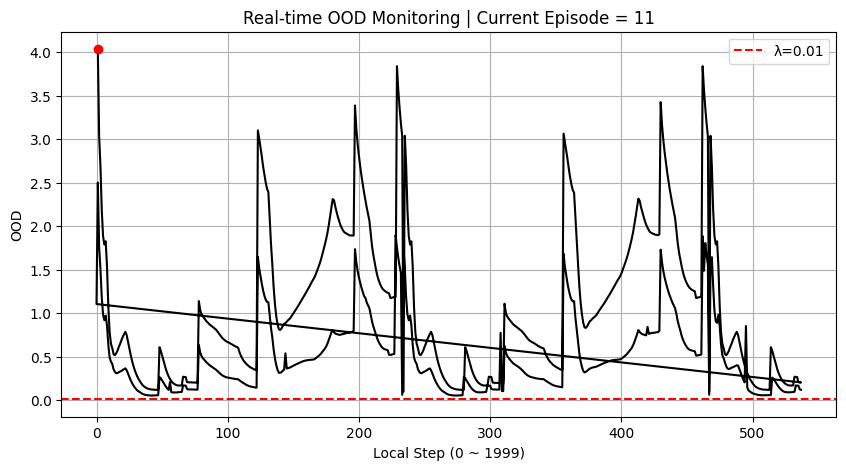

KeyboardInterrupt: 

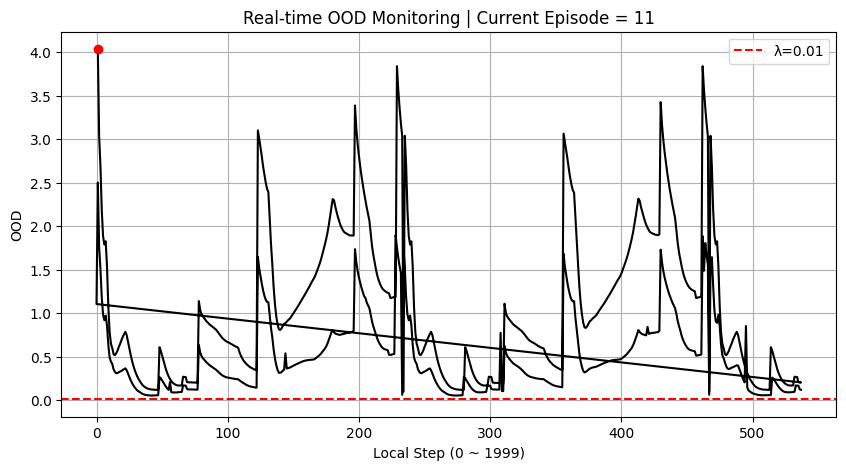

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import time, os

log_path = "/AILAB-summer-school-2025/RND/ood_log.csv"

plt.ion()
fig, ax = plt.subplots(figsize=(10,5))
disp = display(fig, display_id=True)

last_size = 0
STEP_RESET = 2000

while True:
    try:
        current_size = os.path.getsize(log_path)
    except:
        time.sleep(0.5)
        continue

    if current_size == last_size:
        time.sleep(0.2)
        continue
    last_size = current_size

    # ---------------------------------------
    # Load CSV and skip "EPISODE_END" lines
    # ---------------------------------------
    rows = []
    with open(log_path, "r") as f:
        for line in f:
            if line.startswith("EPISODE_END"):
                continue
            
            parts = line.strip().split(",")
            if len(parts) != 4:
                continue
            
            try:
                rows.append([
                    int(parts[0]),   # global_step
                    float(parts[1]), # lambda
                    float(parts[2]), # ood
                    int(parts[3])    # episode
                ])
            except:
                pass

    if len(rows) == 0:
        continue

    df = pd.DataFrame(rows,
                      columns=["global_step","lambda","ood","episode"])

    latest_ep = df["episode"].iloc[-1]

    # ---------------------------------------
    # Local step modulo 6000
    # ---------------------------------------
    df["local_step"] = df["global_step"] % STEP_RESET

    # ---------------------------------------
    # Plot
    # ---------------------------------------
    ax.clear()

    # Draw line with segmentation at modulo resets
    prev = None
    xs, ys = [], []

    for _, row in df.iterrows():
        ls = row["local_step"]
        ood = row["ood"]

        if prev is not None and ls < prev:
            # Reset: draw previous segment
            ax.plot(xs, ys, color="black")
            xs, ys = [], []  # new segment
        
        xs.append(ls)
        ys.append(ood)
        prev = ls

    # last segment
    if len(xs) > 0:
        ax.plot(xs, ys, color="black")

    # ---------------------------------------
    # Lambda horizontal line
    # ---------------------------------------
    lambda_val = df["lambda"].iloc[-1]
    ax.axhline(lambda_val, linestyle='--', color='red',
               label=f"λ={lambda_val}")

    # ---------------------------------------
    # Episode-wise first detection
    # ---------------------------------------
    detections = df[df["ood"] > lambda_val].groupby("episode").first()

    for ep, row in detections.iterrows():
        ax.plot(row["local_step"], row["ood"], 'ro', markersize=5)

    ax.set_title(f"Real-time OOD Monitoring | Current Episode = {latest_ep}")
    ax.set_xlabel("Local Step (0 ~ 5999 looping)")
    ax.set_ylabel("OOD")
    ax.grid(True)
    ax.legend()

    disp.update(fig)
    time.sleep(0.15)



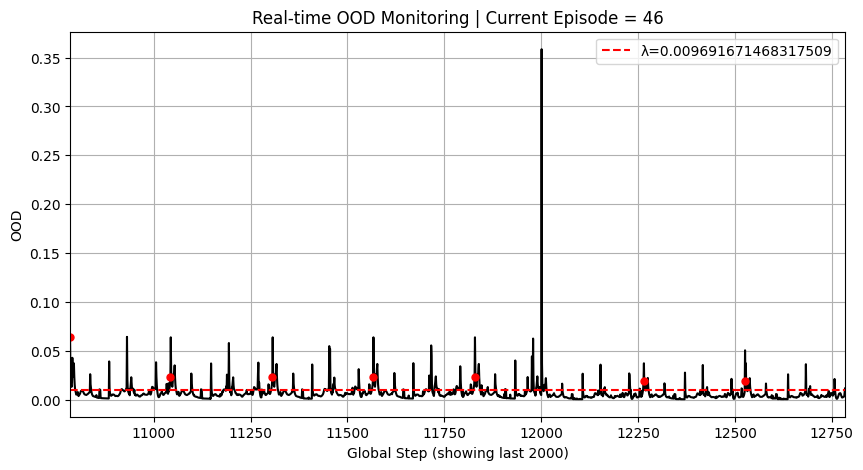

KeyboardInterrupt: 

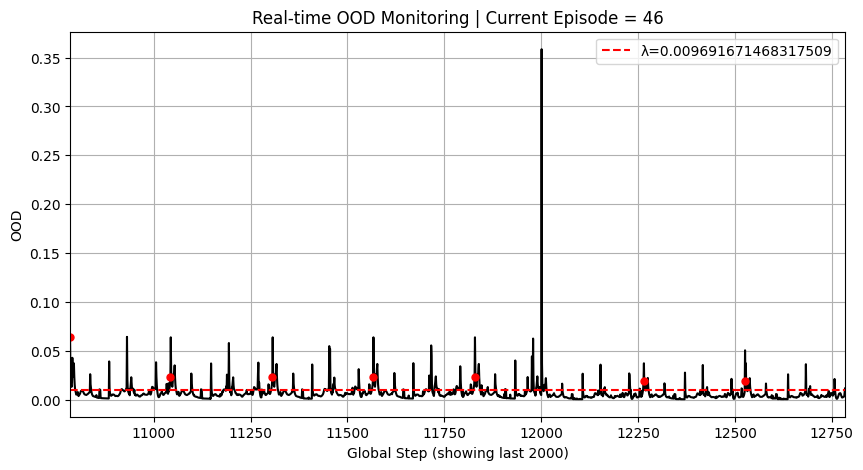

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import time, os

log_path = "/AILAB-summer-school-2025/RND/ood_log.csv"

plt.ion()
fig, ax = plt.subplots(figsize=(10,5))
disp = display(fig, display_id=True)

last_size = 0
STEP_WINDOW = 2000 

while True:
    try:
        current_size = os.path.getsize(log_path)
    except:
        time.sleep(0.5)
        continue

    if current_size == last_size:
        time.sleep(0.2)
        continue
    last_size = current_size

    # ---------------------------------------
    # Load CSV and skip "EPISODE_END" lines
    # ---------------------------------------
    rows = []
    with open(log_path, "r") as f:
        for line in f:
            if line.startswith("EPISODE_END"):
                continue
            
            parts = line.strip().split(",")
            if len(parts) != 4:
                continue
            
            try:
                rows.append([
                    int(parts[0]),   # global_step
                    float(parts[1]), # lambda
                    float(parts[2]), # ood
                    int(parts[3])    # episode
                ])
            except:
                pass

    if len(rows) == 0:
        continue

    df = pd.DataFrame(rows,
                      columns=["global_step","lambda","ood","episode"])

    latest_step = df["global_step"].iloc[-1]
    latest_ep = df["episode"].iloc[-1]

    # ---------------------------------------
    # Sliding window view (global_step 기준)
    # ---------------------------------------
    window_min = max(0, latest_step - STEP_WINDOW)
    df_window = df[df["global_step"] >= window_min]

    # ---------------------------------------
    # Plot (reset only axis, not figure)
    # ---------------------------------------
    ax.clear()

    ax.plot(df_window["global_step"], df_window["ood"], color="black")

    lambda_val = df_window["lambda"].iloc[-1]
    ax.axhline(lambda_val, linestyle='--', color='red',
               label=f"λ={lambda_val}")

    detections = df_window[df_window["ood"] > lambda_val].groupby("episode").first()
    for ep, row in detections.iterrows():
        ax.plot(row["global_step"], row["ood"], 'ro', markersize=5)

    # ---------------------------------------
    # Adjust x-axis to sliding window
    # ---------------------------------------
    ax.set_xlim(window_min, latest_step)

    ax.set_title(f"Real-time OOD Monitoring | Current Episode = {latest_ep}")
    ax.set_xlabel(f"Global Step (showing last {STEP_WINDOW})")
    ax.set_ylabel("OOD")
    ax.grid(True)
    ax.legend()

    disp.update(fig)
    time.sleep(0.1)
